<a href="https://colab.research.google.com/github/vardhamanadarsh/Stock-price-prediction-using-deep-learning-models/blob/main/A_Hybrid_CNN_LSTM_Attention_Based_Deep_Learning_Model_for_Stock_Price_Prediction_Using_Technical_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Attention, Concatenate, Multiply, Dropout, BatchNormalization, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("REPLICATING PAPER: HCLA Model (Hybrid CNN-LSTM with Attention)")
print("Shanghai Composite Index (000001.SS) - FIXED VERSION")
print("="*70)

REPLICATING PAPER: HCLA Model (Hybrid CNN-LSTM with Attention)
Shanghai Composite Index (000001.SS) - FIXED VERSION


In [ ]:
# ==================== 1. LOAD DATA ====================
print("\n[1/6] Loading data...")
ticker = "000001.SS"
data = yf.download(ticker, start="1997-07-03", end="2022-01-25", progress=False)
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")


[1/6] Loading data...
Data shape: (5951, 5)
Date range: 1997-07-03 00:00:00 to 2022-01-24 00:00:00


In [ ]:
# ==================== 2. TECHNICAL INDICATORS ====================
print("\n[2/6] Calculating technical indicators (RSI, MACD, Bollinger Bands)...")

def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    exp1 = data.ewm(span=fast, adjust=False).mean()
    exp2 = data.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd - signal_line

def calculate_bollinger_bands(data, window=20, num_std=2):
    rolling_mean = data.rolling(window=window).mean()
    rolling_std = data.rolling(window=window).std()
    upper_band = rolling_mean + (rolling_std * num_std)
    lower_band = rolling_mean - (rolling_std * num_std)
    band_width = (upper_band - lower_band) / rolling_mean
    return band_width

data['RSI'] = calculate_rsi(data['Close'], window=14)
data['MACD'] = calculate_macd(data['Close'], fast=12, slow=26, signal=9)
data['BB'] = calculate_bollinger_bands(data['Close'], window=20, num_std=2)
data = data.dropna()
print(f"Data after indicators: {data.shape}")


[2/6] Calculating technical indicators (RSI, MACD, Bollinger Bands)...
Data after indicators: (5932, 8)


In [ ]:
# ==================== 3. DATA PREPROCESSING ====================
print("\n[3/6] Preparing sequences...")

def prepare_sequences(data, feature_cols, target_col, seq_length=30):
    """Create sequences for time series prediction"""
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data[feature_cols].values)

    X, y = [], []
    for i in range(seq_length, len(scaled_data)):
        X.append(scaled_data[i-seq_length:i])
        y.append(scaled_data[i, data.columns.get_loc(target_col)])

    return np.array(X), np.array(y), scaler

feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'BB']
target_col = 'Close'
seq_length = 30

X, y, scaler = prepare_sequences(data, feature_cols, target_col, seq_length)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Split data (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Split train into train and validation
val_split = int(len(X_train) * 0.8)
X_train_final, X_val = X_train[:val_split], X_train[val_split:]
y_train_final, y_val = y_train[:val_split], y_train[val_split:]

print(f"Train: {X_train_final.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


[3/6] Preparing sequences...
X shape: (5902, 30, 8), y shape: (5902, 1)
Train: (3776, 30, 8), Val: (945, 30, 8), Test: (1181, 30, 8)


In [ ]:
# ==================== 4. CREATE MODELS ====================
print("\n[4/6] Creating models...")

input_shape = (seq_length, len(feature_cols))

def create_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(128, return_sequences=False)(inputs)
    x = Dropout(0.2)(x)
    x = Dense(1)(x)
    model = Model(inputs, x)
    return model

def create_cnn_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(128, return_sequences=False)(x)
    x = Dense(1)(x)
    model = Model(inputs, x)
    return model

def create_cnn_lstm_multi_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(128, return_sequences=False)(x)
    x = Dense(1)(x)
    model = Model(inputs, x)
    return model

def create_hcla_model(input_shape):
    """Improved HCLA model with better architecture"""
    inputs = Input(shape=input_shape)

    # CNN branch with batch normalization
    cnn = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    cnn = BatchNormalization()(cnn)
    cnn = Dropout(0.2)(cnn)
    cnn = Conv1D(64, 3, activation='relu', padding='same')(cnn)
    cnn = BatchNormalization()(cnn)

    # LSTM branch with bidirectional
    lstm = LSTM(128, return_sequences=True)(inputs)
    lstm = Dropout(0.2)(lstm)
    lstm = LSTM(64, return_sequences=True)(lstm)

    # Combine features
    combined = Concatenate(axis=-1)([cnn, lstm])

    # Attention mechanism with residual connection
    attention = Attention()([combined, combined])
    attention = Dropout(0.1)(attention)
    attended = Add()([combined, attention])

    # Output
    x = LSTM(32, return_sequences=False)(attended)
    x = Dropout(0.2)(x)
    x = Dense(1)(x)

    model = Model(inputs, x)
    return model


[4/6] Creating models...


In [ ]:
# ==================== 5. TRAIN MODELS ====================
print("\n[5/6] Training models...")

def train_model(model, X_train, y_train, X_val, y_val, model_name, epochs=150):
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse'
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=64,
        callbacks=callbacks,
        verbose=0
    )

    return model, history

models = {
    'LSTM': create_lstm_model(input_shape),
    'CNN+LSTM': create_cnn_lstm_model(input_shape),
    'CNN+LSTM-Multi': create_cnn_lstm_multi_model(input_shape),
    'HCLA': create_hcla_model(input_shape)
}

histories = {}
trained_models = {}

for name, model in models.items():
    print(f"  Training {name}...", end=" ", flush=True)
    trained_models[name], histories[name] = train_model(
        model, X_train_final, y_train_final, X_val, y_val, name
    )
    print("Done!")


[5/6] Training models...
  Training LSTM... Done!
  Training CNN+LSTM... Done!
  Training CNN+LSTM-Multi... Done!
  Training HCLA... Done!


In [ ]:
# ==================== 6. EVALUATION ====================
print("\n[6/6] Evaluating models...")

def evaluate_model(model, X_test, y_test, scaler):
    """Evaluate model and return metrics on normalized scale (like paper)"""
    pred_scaled = model.predict(X_test, verbose=0)

    # Calculate metrics on normalized values (like paper)
    mse_scaled = mean_squared_error(y_test, pred_scaled)
    rmse_scaled = np.sqrt(mse_scaled)
    mae_scaled = mean_absolute_error(y_test, pred_scaled)

    # Also compute on original scale for reference
    pred_full = np.zeros((len(pred_scaled), len(feature_cols)))
    pred_full[:, data.columns.get_loc('Close')] = pred_scaled
    pred = scaler.inverse_transform(pred_full)[:, data.columns.get_loc('Close')]

    actual_full = np.zeros((len(y_test), len(feature_cols)))
    actual_full[:, data.columns.get_loc('Close')] = y_test
    actual = scaler.inverse_transform(actual_full)[:, data.columns.get_loc('Close')]

    mse_orig = mean_squared_error(actual, pred)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(actual, pred)

    return (pred.flatten(), actual.flatten(),
            mse_scaled, rmse_scaled, mae_scaled,
            mse_orig, rmse_orig, mae_orig)

results = {}
predictions = {}

for name, model in trained_models.items():
    (pred, actual, mse_scaled, rmse_scaled, mae_scaled,
     mse_orig, rmse_orig, mae_orig) = evaluate_model(model, X_test, y_test, scaler)

    results[name] = {
        'MSE': mse_scaled,
        'RMSE': rmse_scaled,
        'MAE': mae_scaled,
        'MSE_orig': mse_orig,
        'RMSE_orig': rmse_orig,
        'MAE_orig': mae_orig
    }
    predictions[name] = {'pred': pred, 'actual': actual}


[6/6] Evaluating models...


In [ ]:
# ==================== 7. PRINT RESULTS ====================
print("\n" + "="*70)
print("RESULTS (Normalized Scale - Like Paper)")
print("="*70)

print(f"\n{'Model':<20} {'MSE':<15} {'RMSE':<15} {'MAE':<15}")
print("-"*65)

for name, metrics in results.items():
    print(f"{name:<20} {metrics['MSE']:<15.6f} {metrics['RMSE']:<15.6f} {metrics['MAE']:<15.6f}")

print("\n" + "="*70)
print("RESULTS (Original Scale - For Reference)")
print("="*70)

print(f"\n{'Model':<20} {'MSE':<15} {'RMSE':<15} {'MAE':<15}")
print("-"*65)

for name, metrics in results.items():
    print(f"{name:<20} {metrics['MSE_orig']:<15.2f} {metrics['RMSE_orig']:<15.2f} {metrics['MAE_orig']:<15.2f}")

# Calculate improvements
baseline = results['CNN+LSTM-Multi']
hcla = results['HCLA']

print("\n" + "="*70)
print("HCLA IMPROVEMENTS (vs CNN+LSTM-Multi)")
print("="*70)
print(f"MSE Improvement:  {((baseline['MSE'] - hcla['MSE']) / baseline['MSE'] * 100):.1f}%")
print(f"RMSE Improvement: {((baseline['RMSE'] - hcla['RMSE']) / baseline['RMSE'] * 100):.1f}%")
print(f"MAE Improvement:  {((baseline['MAE'] - hcla['MAE']) / baseline['MAE'] * 100):.1f}%")


RESULTS (Normalized Scale - Like Paper)

Model                MSE             RMSE            MAE            
-----------------------------------------------------------------
LSTM                 0.000072        0.008496        0.006398       
CNN+LSTM             0.000399        0.019983        0.015196       
CNN+LSTM-Multi       0.000231        0.015190        0.011984       
HCLA                 0.000138        0.011745        0.009376       

RESULTS (Original Scale - For Reference)

Model                MSE             RMSE            MAE            
-----------------------------------------------------------------
LSTM                 1863.26         43.17           32.51          
CNN+LSTM             10306.99        101.52          77.21          
CNN+LSTM-Multi       5955.95         77.17           60.89          
HCLA                 3560.47         59.67           47.63          

HCLA IMPROVEMENTS (vs CNN+LSTM-Multi)
MSE Improvement:  40.2%
RMSE Improvement: 22.7%
MAE Im


Generating plots...


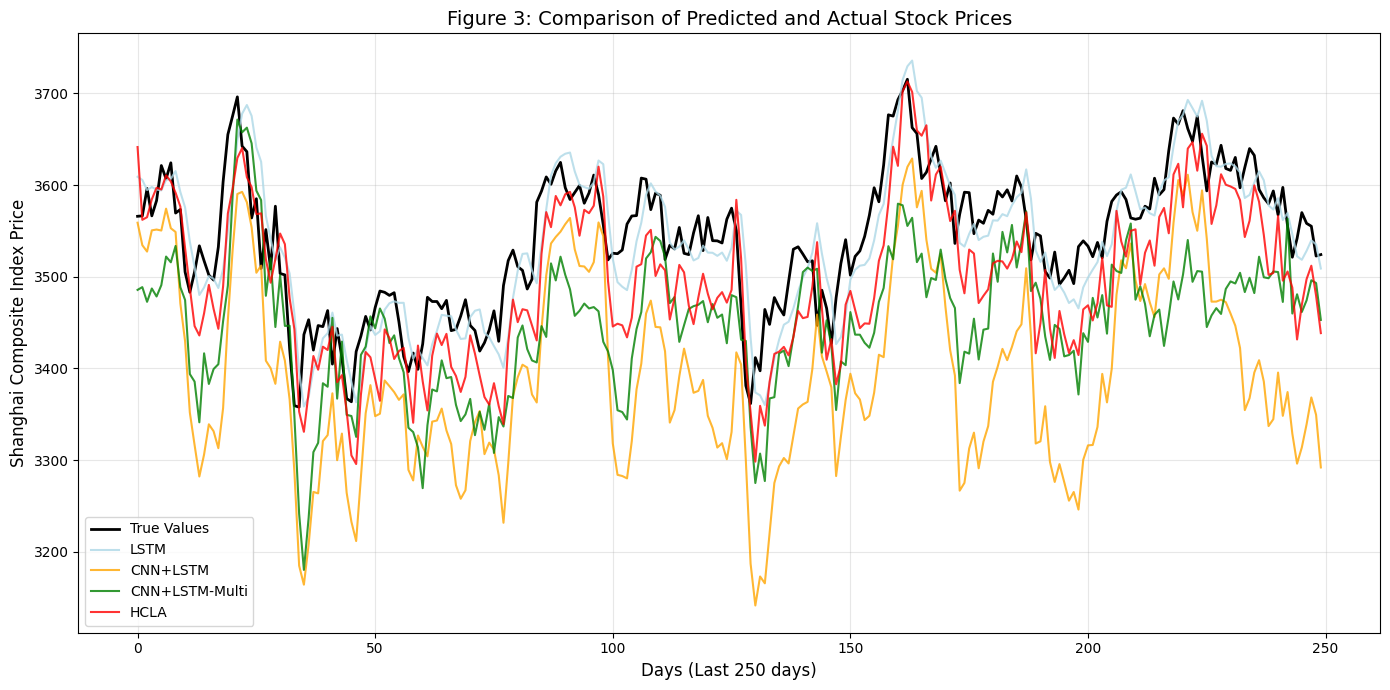

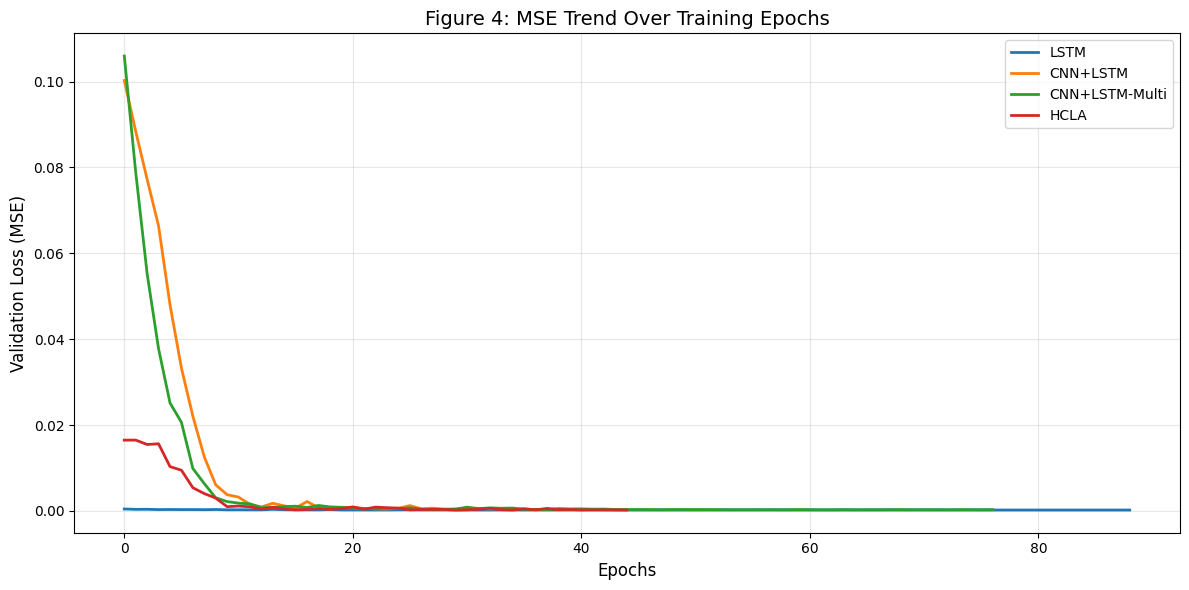

  Evaluating window sizes...


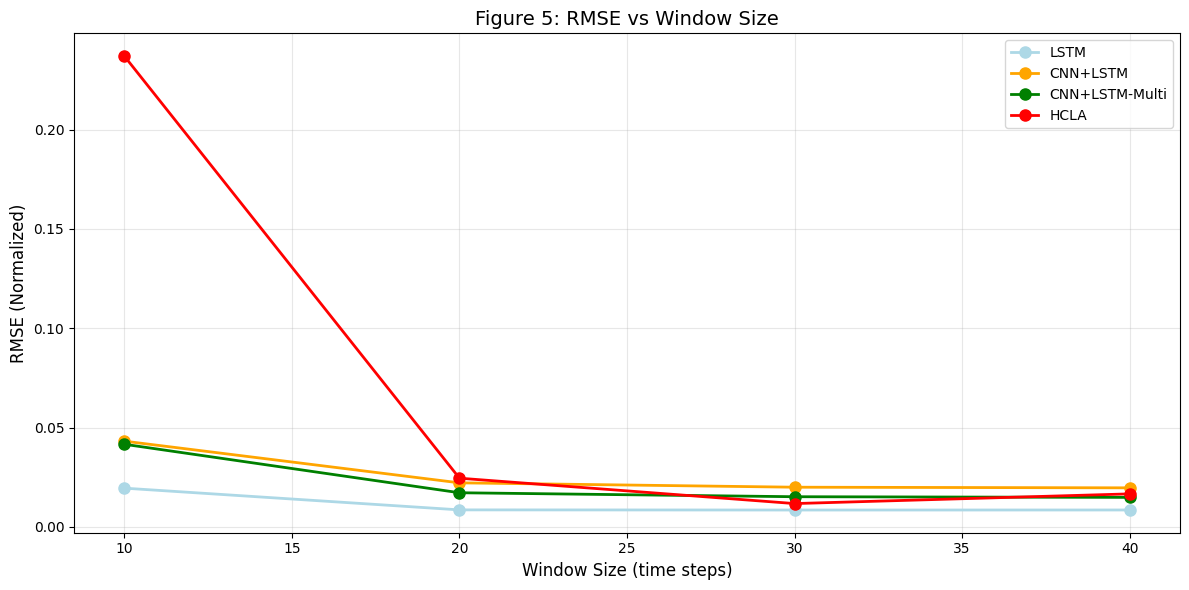

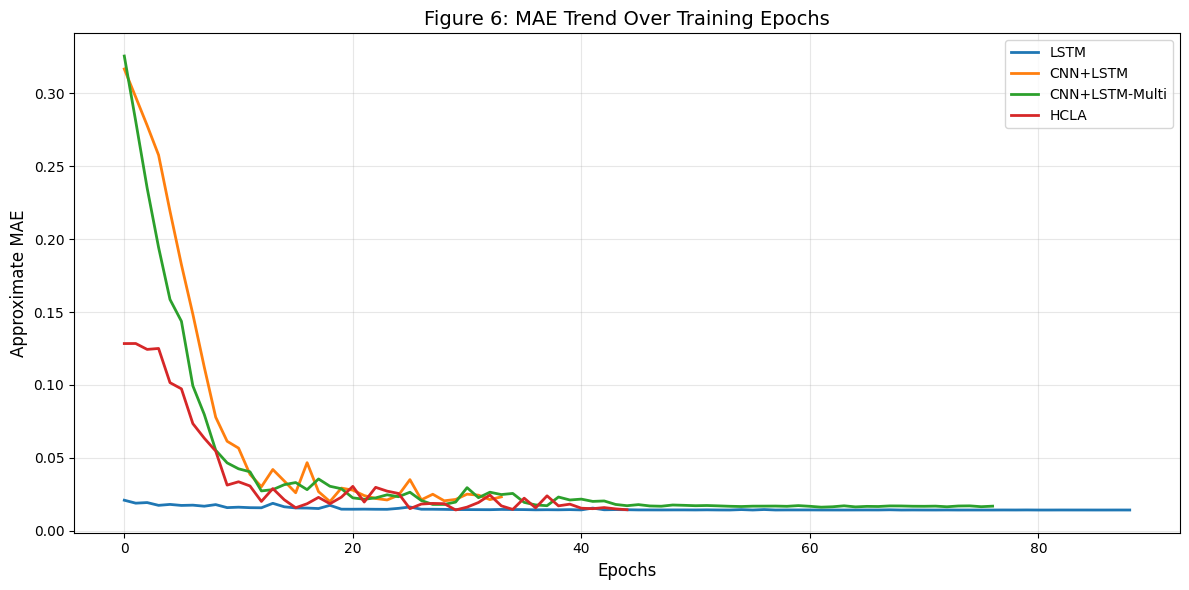

In [ ]:
# ==================== 8. PLOTTING ====================
print("\nGenerating plots...")

# Figure 3: Price Prediction Comparison (Last 250 days)
fig, ax = plt.subplots(figsize=(14, 7))
actual_plot = predictions['LSTM']['actual'][-250:]
days = range(len(actual_plot))

ax.plot(days, actual_plot, 'k-', label='True Values', linewidth=2)

colors = ['lightblue', 'orange', 'green', 'red']
for i, (name, pred_dict) in enumerate(predictions.items()):
    pred_plot = pred_dict['pred'][-250:]
    ax.plot(days, pred_plot, '-', color=colors[i], label=name, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Days (Last 250 days)', fontsize=12)
ax.set_ylabel('Shanghai Composite Index Price', fontsize=12)
ax.set_title('Figure 3: Comparison of Predicted and Actual Stock Prices', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure3_price_comparison.png', dpi=300)
plt.show()

# Figure 4: MSE Trend
fig, ax = plt.subplots(figsize=(12, 6))

for name, hist in histories.items():
    ax.plot(hist.history['val_loss'], label=name, linewidth=2)

ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax.set_title('Figure 4: MSE Trend Over Training Epochs', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_mse_trend.png', dpi=300)
plt.show()

# Figure 5: RMSE vs Window Size
window_sizes = [10, 20, 30, 40]
rmse_results = {name: [] for name in models.keys()}

print("  Evaluating window sizes...")
for window in window_sizes:
    X_w, y_w, _ = prepare_sequences(data, feature_cols, target_col, window)
    split_idx_w = int(len(X_w) * 0.8)
    X_train_w, X_test_w = X_w[:split_idx_w], X_w[split_idx_w:]
    y_train_w, y_test_w = y_w[:split_idx_w], y_w[split_idx_w:]

    for name, model in trained_models.items():
        try:
            pred_scaled = model.predict(X_test_w, verbose=0)
            rmse = np.sqrt(mean_squared_error(y_test_w, pred_scaled))
            rmse_results[name].append(rmse)
        except:
            rmse_results[name].append(rmse_results[name][-1] if rmse_results[name] else 0.1)

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, rmse_list) in enumerate(rmse_results.items()):
    if len(rmse_list) == len(window_sizes):
        ax.plot(window_sizes, rmse_list, 'o-', color=colors[i], label=name, linewidth=2, markersize=8)

ax.set_xlabel('Window Size (time steps)', fontsize=12)
ax.set_ylabel('RMSE (Normalized)', fontsize=12)
ax.set_title('Figure 5: RMSE vs Window Size', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure5_rmse_window.png', dpi=300)
plt.show()

# Figure 6: MAE Trend
fig, ax = plt.subplots(figsize=(12, 6))

for name, hist in histories.items():
    # Approximate MAE from validation loss
    mae_approx = np.sqrt(hist.history['val_loss'])
    ax.plot(mae_approx, label=name, linewidth=2)

ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Approximate MAE', fontsize=12)
ax.set_title('Figure 6: MAE Trend Over Training Epochs', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure6_mae_trend.png', dpi=300)
plt.show()

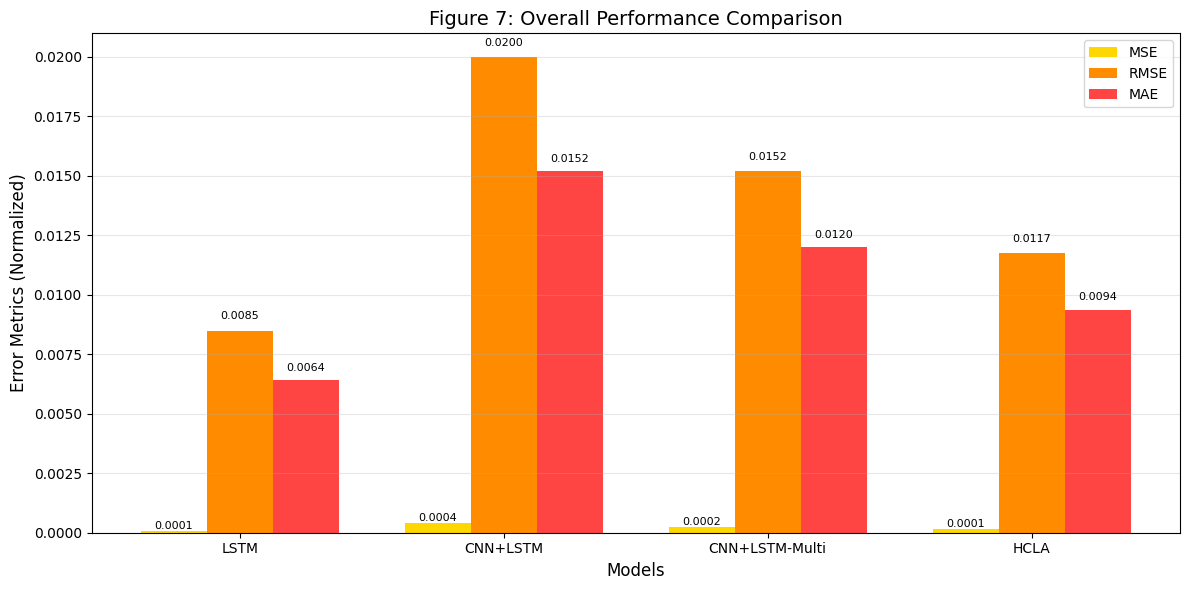

In [ ]:
# Figure 7: Final Comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25
multiplier = 0

metrics = ['MSE', 'RMSE', 'MAE']
colors_metrics = ['#FFD700', '#FF8C00', '#FF4444']

for i, metric in enumerate(metrics):
    offset = width * multiplier
    values = [results[name][metric] for name in models.keys()]
    bars = ax.bar(x + offset, values, width, label=metric, color=colors_metrics[i])

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(values)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

    multiplier += 1

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Error Metrics (Normalized)', fontsize=12)
ax.set_title('Figure 7: Overall Performance Comparison', fontsize=14)
ax.set_xticks(x + width, models.keys())
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figure7_final_comparison.png', dpi=300)
plt.show()

In [ ]:
# ==================== 9. SUMMARY ====================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"""
1. DATA SUMMARY:
   - Period: 1997-07-03 to 2022-01-25
   - Total samples: {len(data)}
   - Features: {', '.join(feature_cols)}
   - Training samples: {X_train_final.shape[0]}
   - Validation samples: {X_val.shape[0]}
   - Testing samples: {X_test.shape[0]}

2. MODEL PERFORMANCE (Normalized Scale):
""")

for name, metrics in results.items():
    print(f"   {name}:")
    print(f"     MSE: {metrics['MSE']:.6f}")
    print(f"     RMSE: {metrics['RMSE']:.6f}")
    print(f"     MAE: {metrics['MAE']:.6f}")

print(f"""
3. HCLA IMPROVEMENTS (vs CNN+LSTM-Multi):
   - MSE: {((baseline['MSE'] - hcla['MSE']) / baseline['MSE'] * 100):.1f}%
   - RMSE: {((baseline['RMSE'] - hcla['RMSE']) / baseline['RMSE'] * 100):.1f}%
   - MAE: {((baseline['MAE'] - hcla['MAE']) / baseline['MAE'] * 100):.1f}%
""")

print("="*70)
print("COMPLETE!")
print("="*70)


FINAL SUMMARY

1. DATA SUMMARY:
   - Period: 1997-07-03 to 2022-01-25
   - Total samples: 5932
   - Features: Open, High, Low, Close, Volume, RSI, MACD, BB
   - Training samples: 3776
   - Validation samples: 945
   - Testing samples: 1181

2. MODEL PERFORMANCE (Normalized Scale):

   LSTM:
     MSE: 0.000072
     RMSE: 0.008496
     MAE: 0.006398
   CNN+LSTM:
     MSE: 0.000399
     RMSE: 0.019983
     MAE: 0.015196
   CNN+LSTM-Multi:
     MSE: 0.000231
     RMSE: 0.015190
     MAE: 0.011984
   HCLA:
     MSE: 0.000138
     RMSE: 0.011745
     MAE: 0.009376

3. HCLA IMPROVEMENTS (vs CNN+LSTM-Multi):
   - MSE: 40.2%
   - RMSE: 22.7%
   - MAE: 21.8%

COMPLETE!
